<a href="https://colab.research.google.com/github/bdh283ako/nurmosenkurssi/blob/main/tehtava5_lineaarinen_optimointi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# =====================================================================
# TEHTÄVÄ 5: LINEAARINEN OPTIMOINTI (PYTHON & SCIPY)
# =====================================================================

"""
OHJEET PERUSKÄYTTÄJÄLLE:
1. Koodin suorittaminen: Paina solun vasemmassa yläkulmassa olevaa
   "Play"-painiketta tai käytä pikanäppäintä Shift + Enter.
2. Arvojen muuttaminen: Koodissa on selkeästi nimetyt muuttujat,
   kuten "katteet" tai "investointi_kulu". Voit muuttaa näitä lukuja
   vapaasti ja ajaa koodin uudelleen nähdäksesi uudet tulokset.

OHJEET KEHITTÄJÄLLE (Miten malli toimii):
* Kirjastot: Käytämme scipy.optimize -kirjaston milp-funktiota
  (Mixed-Integer Linear Programming). Käytämme tätä jatkuvan optimoinnin
  (linprog) sijaan, koska tuotteiden kappalemäärien on oltava ehyitä kokonaislukuja.
* Kohdefunktio: SciPy minimoi arvoja oletuksena. Maksimoidaksemme katteen,
  käännämme katteiden etumerkit negatiivisiksi (esim. -250).
* Rajoitteet: Työvaiheiden minuutit annetaan matriisina A ja maksimikapasiteetit
  vektorina b. Optimoijan ehto on matemaattisesti A * x <= b.
"""

import numpy as np
from scipy.optimize import milp, LinearConstraint, Bounds

print("="*50)
print("1 & 2: PERUSTILANTEEN OPTIMOINTI (Hila ja Vitkutin)")
print("="*50)

# Katteet: Hila = 250 €, Vitkutin = 320 €
katteet = np.array([250, 320])
c = -katteet # Käännetään negatiiviseksi maksimointia varten

# Rajoitematriisi (A): Kuinka monta minuuttia kukin tuote vaatii.
# Riveittäin: Leikkaus, Stanssaus, Puristus, Maalaus
A = np.array([
    [12, 20],
    [16,  7],
    [12,  6],
    [22, 15]
])

# Työvaiheiden maksimikapasiteetit minuutteina (b)
b = np.array([25000, 30000, 30000, 20000])

# Rajoitusten ja sääntöjen määrittely
constraints = LinearConstraint(A, -np.inf, b)
bounds = Bounds(0, np.inf) # Tuotantomäärä ei voi olla negatiivinen
integrality = np.ones_like(c) # Pakotetaan tulos kokonaisluvuiksi (1)

# Suoritetaan optimointi
res = milp(c=c, constraints=constraints, integrality=integrality, bounds=bounds)

if res.success:
    peruskate = int(-res.fun)
    print(f"Optimaalinen tuotanto-ohjelma:")
    print(f" - Hila: {int(res.x[0])} kpl")
    print(f" - Vitkutin: {int(res.x[1])} kpl")
    print(f"Maksimikate: {peruskate} €\n")


print("="*50)
print("3: KAPASITEETIN LISÄYKSEN SIMULOINTI (25 000 €)")
print("="*50)
print("Testataan, mihin työvaiheeseen investointi kannattaa kohdistaa.\n")

investointi_kulu = 25000
tyovaiheet = ['Leikkaus', 'Stanssaus', 'Puristus', 'Maalaus']
paras_netto = 0
paras_vaihe = ""

# Käydään for-silmukalla läpi kaikki 4 työvaihetta
for i in range(4):
    b_uusi = b.copy()
    b_uusi[i] += 25000 # Lisätään 25000 minuuttia testattavaan työvaiheeseen

    # Ratkaistaan ongelma uudella kapasiteetilla
    constr_uusi = LinearConstraint(A, -np.inf, b_uusi)
    res_uusi = milp(c=c, constraints=constr_uusi, integrality=integrality, bounds=bounds)

    uusi_kate = int(-res_uusi.fun)
    katteen_kasvu = uusi_kate - peruskate
    nettohyoty = katteen_kasvu - investointi_kulu

    print(f"Jos investoidaan {tyovaiheet[i]}vaiheeseen:")
    print(f"  -> Uusi kate: {uusi_kate} € (Nettohyöty kulu huomioiden: {nettohyoty} €)")

    # Tallennetaan paras tulos muistiin
    if nettohyoty > paras_netto:
        paras_netto = nettohyoty
        paras_vaihe = tyovaiheet[i]

print("-" * 50)
print(f"JOHTOPÄÄTÖS: Kannattaa investoida työvaiheeseen: {paras_vaihe}.")
print(f"Tämä tuo yritykselle {paras_netto} euroa puhdasta nettohyötyä.\n")


print("="*50)
print("4: KOLMEN TUOTTEEN OPTIMOINTI (Vilunki mukana)")
print("="*50)
print("Palautetaan alkuperäiset kapasiteetit ja lisätään uusi tuote.\n")

# Uudet katteet (Hila, Vitkutin, Vilunki)
c_vil = -np.array([250, 320, 350])

# Päivitetään matriisi Vilungin vaatimilla minuuteilla (0, 20, 10, 25)
A_vil = np.array([
    [12, 20,  0],
    [16,  7, 20],
    [12,  6, 10],
    [22, 15, 25]
])

integrality_vil = np.ones_like(c_vil)
bounds_vil = Bounds(0, np.inf)
constraints_vil = LinearConstraint(A_vil, -np.inf, b) # Käytetään taas alkuperäistä b:tä

# Suoritetaan uusi optimointi kolmella tuotteella
res_vil = milp(c=c_vil, constraints=constraints_vil, integrality=integrality_vil, bounds=bounds_vil)

if res_vil.success:
    print(f"Optimaalinen tuotanto-ohjelma:")
    print(f" - Hila: {int(res_vil.x[0])} kpl")
    print(f" - Vitkutin: {int(res_vil.x[1])} kpl")
    print(f" - Vilunki: {int(res_vil.x[2])} kpl")
    print(f"Maksimikate: {int(-res_vil.fun)} €")

1 & 2: PERUSTILANTEEN OPTIMOINTI (Hila ja Vitkutin)
Optimaalinen tuotanto-ohjelma:
 - Hila: 94 kpl
 - Vitkutin: 1193 kpl
Maksimikate: 405510 €

3: KAPASITEETIN LISÄYKSEN SIMULOINTI (25 000 €)
Testataan, mihin työvaiheeseen investointi kannattaa kohdistaa.

Jos investoidaan Leikkausvaiheeseen:
  -> Uusi kate: 426560 € (Nettohyöty kulu huomioiden: -3950 €)
Jos investoidaan Stanssausvaiheeseen:
  -> Uusi kate: 405510 € (Nettohyöty kulu huomioiden: -25000 €)
Jos investoidaan Puristusvaiheeseen:
  -> Uusi kate: 405510 € (Nettohyöty kulu huomioiden: -25000 €)
Jos investoidaan Maalausvaiheeseen:
  -> Uusi kate: 504400 € (Nettohyöty kulu huomioiden: 73890 €)
--------------------------------------------------
JOHTOPÄÄTÖS: Kannattaa investoida työvaiheeseen: Maalaus.
Tämä tuo yritykselle 73890 euroa puhdasta nettohyötyä.

4: KOLMEN TUOTTEEN OPTIMOINTI (Vilunki mukana)
Palautetaan alkuperäiset kapasiteetit ja lisätään uusi tuote.

Optimaalinen tuotanto-ohjelma:
 - Hila: 0 kpl
 - Vitkutin: 1250 kp

**Leikitään graafilla - ei kuulu tehtävänantoon.**

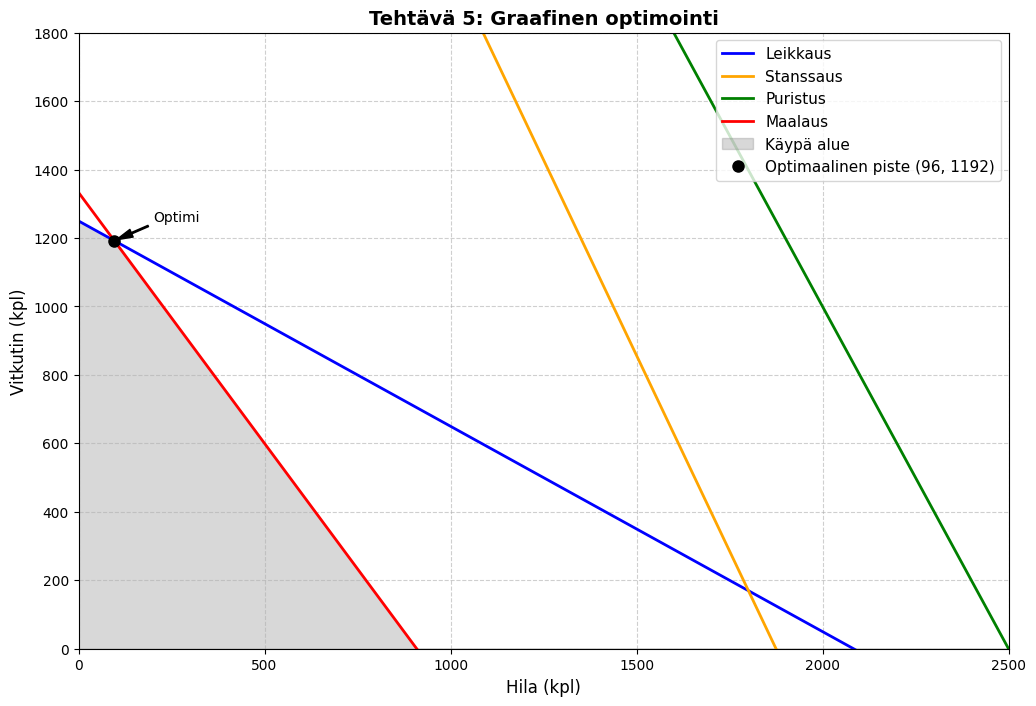

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Luodaan x-akselin arvot (Hila-tuotteen määrä 0-2500 kpl)
x = np.linspace(0, 2500, 500)

# 2. Määritellään rajoiteyhtälöt (y = Vitkutin)
# Ratkaistu muotoon y = (Kapasiteetti - x_minuutit) / y_minuutit
y_leikkaus = (25000 - 12 * x) / 20
y_stanssaus = (30000 - 16 * x) / 7
y_puristus = (30000 - 12 * x) / 6
y_maalaus = (20000 - 22 * x) / 15

# 3. Määritetään käypä alue (feasible region) eli alin mahdollinen raja
# Käypä alue ei voi olla negatiivinen (y >= 0)
y_min = np.minimum.reduce([y_leikkaus, y_stanssaus, y_puristus, y_maalaus])
y_min = np.maximum(y_min, 0)

# 4. Piirretään kaavio
plt.figure(figsize=(12, 8))

# Piirretään työvaiheiden suorat
plt.plot(x, y_leikkaus, label='Leikkaus', color='blue', linewidth=2)
plt.plot(x, y_stanssaus, label='Stanssaus', color='orange', linewidth=2)
plt.plot(x, y_puristus, label='Puristus', color='green', linewidth=2)
plt.plot(x, y_maalaus, label='Maalaus', color='red', linewidth=2)

# Värjätään käypä alue
plt.fill_between(x, 0, y_min, color='gray', alpha=0.3, label='Käypä alue')

# Merkitään optimaalinen piste (Perustilanne: Hila n. 96, Vitkutin n. 1192)
plt.plot(96.15, 1192.31, 'ko', markersize=8, label='Optimaalinen piste (96, 1192)')
plt.annotate('Optimi', xy=(96.15, 1192.31), xytext=(200, 1250),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6))

# Asetetaan akselien rajat ja nimet
plt.xlim(0, 2500)
plt.ylim(0, 1800)
plt.title('Tehtävä 5: Graafinen optimointi', fontsize=14, fontweight='bold')
plt.xlabel('Hila (kpl)', fontsize=12)
plt.ylabel('Vitkutin (kpl)', fontsize=12)

# Lisätään ruudukko ja selite
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right', fontsize=11)

# Näytetään kaavio
plt.show()